In [50]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [51]:
#Load and read dataset
df = pd.read_csv('D:\\Data Science & Analytics Internship\\Task 5 Personal Loan Acceptance Prediction\\bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [52]:
#Check missing values
df.info()
#df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [53]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

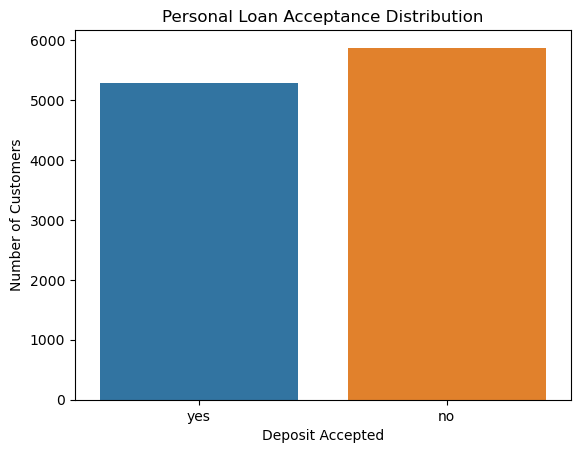

In [54]:
#Visualize data

sns.countplot(x='deposit', data=df)
plt.title("Personal Loan Acceptance Distribution")
plt.xlabel("Deposit Accepted")
plt.ylabel("Number of Customers")
plt.show()

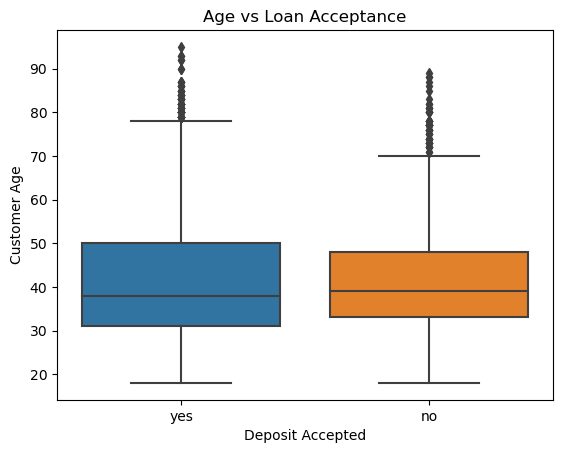

In [55]:
sns.boxplot(x='deposit', y='age', data=df)
plt.title("Age vs Loan Acceptance")
plt.xlabel("Deposit Accepted")
plt.ylabel("Customer Age")
plt.show()

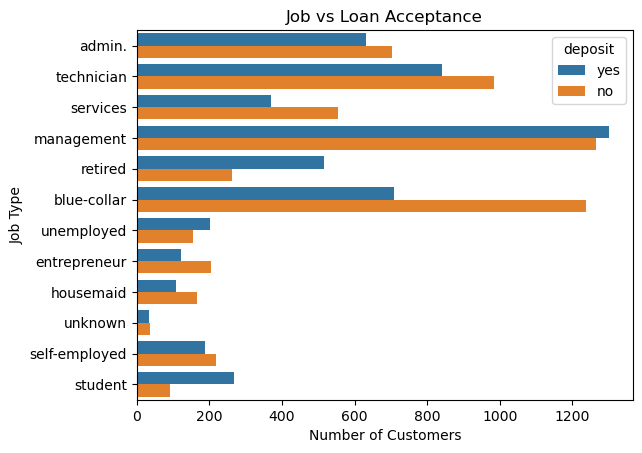

In [56]:
sns.countplot(y='job', hue='deposit', data=df)
plt.title("Job vs Loan Acceptance")
plt.xlabel("Number of Customers")
plt.ylabel("Job Type")
plt.show()

In [57]:
#encode categorical values

df_encoded = pd.get_dummies(df, drop_first=True)
#df_encoded

In [58]:
#split features and target

X = df_encoded.drop('deposit_yes', axis=1)
y = df_encoded['deposit_yes']

In [59]:
#test model performance on unseen data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
#train logistic regression model

#model = LogisticRegression(max_iter=1000)
#model.fit(X_train, y_train)

#train decision tree model

model = DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [61]:
#make predictions
y_pred = model.predict(X_test)

In [62]:
#evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 79.48947604120018 %

Confusion Matrix:
 [[925 241]
 [217 850]]

Classification Report:
               precision    recall  f1-score   support

       False       0.81      0.79      0.80      1166
        True       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



From EDA and model results, we observe:

1. Customers aged 30–50 are more likely to accept loans

2. Customers with stable jobs (management, admin, technician) show higher acceptance

3. Married customers are more responsive to loan offers

4. Targeted marketing can significantly improve success rate